Loaded: 96871 listings
                 id      host_id  neighbourhood_group  latitude  longitude  \
count  9.687100e+04      96871.0                  0.0   96871.0    96871.0   
mean   6.894448e+17  214449413.7                  NaN      51.5       -0.1   
std    5.941222e+17  219605286.6                  NaN       0.0        0.1   
min    1.391300e+04       2594.0                  NaN      51.3       -0.5   
25%    3.026058e+07   27268143.5                  NaN      51.5       -0.2   
50%    8.505248e+17  116432057.0                  NaN      51.5       -0.1   
75%    1.254262e+18  419897445.0                  NaN      51.5       -0.1   
max    1.508964e+18  718690455.0                  NaN      51.7        0.3   

           price  minimum_nights  number_of_reviews  reviews_per_month  \
count    61963.0         96871.0            96871.0            72749.0   
mean       229.9             5.4               21.7                1.0   
std       4437.6            23.7               50.4 

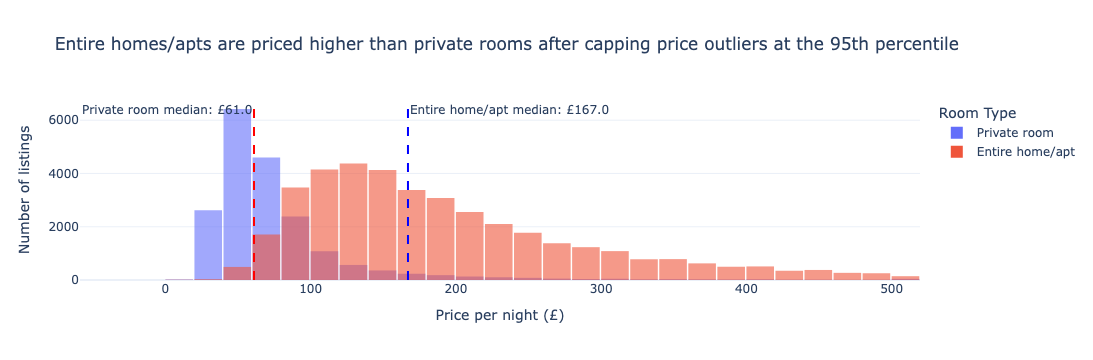

In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1. Load CSV file


df = pd.read_csv("Airbnb_listing_week5.csv")

print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


# ------------------------------------------------------------
# 2. Cap price outliers at 95th percentile
# ------------------------------------------------------------

p95 = df["price"].quantile(0.95)

df_cap = df[df["price"] <= p95].copy()

print(f"\n95th percentile price cap: £{p95:.0f}")
print(df_cap.groupby("room_type")["price"].describe().round(1))


# ------------------------------------------------------------
# 3. Keep only Entire home/apt and Private room
# ------------------------------------------------------------

df_task1 = df_cap[
    df_cap["room_type"].isin(["Entire home/apt", "Private room"])
].copy()

print(f"\nTask 1 dataset size: {len(df_task1)} listings")
print(df_task1["room_type"].value_counts())


# ------------------------------------------------------------
# 4. Calculate median price for each room type
# ------------------------------------------------------------

medians = df_task1.groupby("room_type")["price"].median().round(1)

entire_median = medians["Entire home/apt"]
private_median = medians["Private room"]

print("\nMedian prices:")
print(medians)


# ------------------------------------------------------------
# 5. Plotly Express histogram first
# ------------------------------------------------------------

fig = px.histogram(
    df_task1,
    x="price",
    color="room_type",
    nbins=35,
    opacity=0.6,
    barmode="overlay",
    title=(
        "Entire homes/apts are priced higher than private rooms "
        "after capping price outliers at the 95th percentile"
    ),
    labels={
        "price": "Price per night (£)",
        "room_type": "Room Type"
    }
)


# ------------------------------------------------------------
# 6. Graph Objects additions: median reference lines
# ------------------------------------------------------------

fig.add_vline(
    x=entire_median,
    line_dash="dash",
    line_color="blue",
    annotation_text=f"Entire home/apt median: £{entire_median}",
    annotation_position="top right"
)

fig.add_vline(
    x=private_median,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Private room median: £{private_median}",
    annotation_position="top left"
)


# ------------------------------------------------------------
# 7. Final layout
# ------------------------------------------------------------

fig.update_layout(
    xaxis_title="Price per night (£)",
    yaxis_title="Number of listings",
    legend_title_text="Room Type",
    bargap=0.05,
    template="plotly_white"
)

fig.show()

Using borough column: neighbourhood
Task 2 dataset size after removing zero-review listings: 72749
Two most active boroughs:
neighbourhood
Westminster       0.800
City of London    0.725
Name: reviews_per_month, dtype: float64

Overall median reviews per month: 0.52


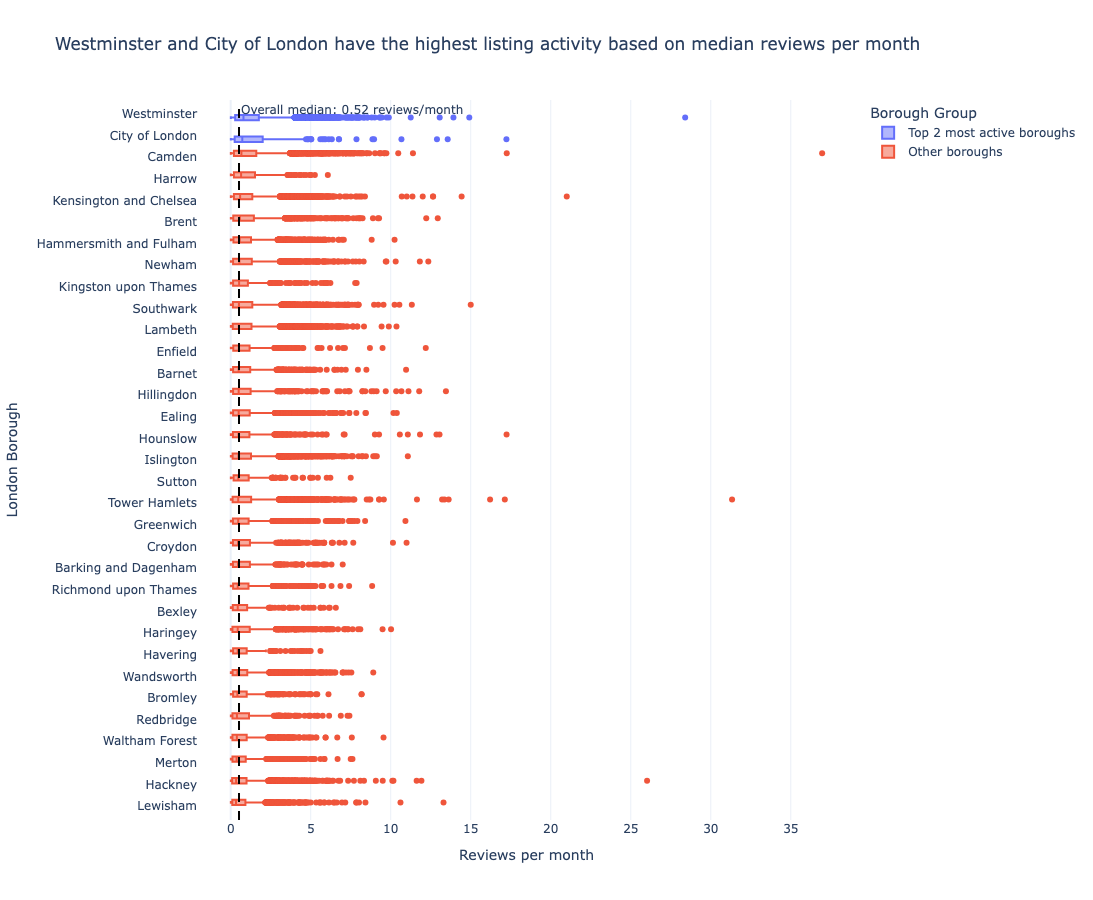

In [4]:
# ------------------------------------------------------------
# Task 2 — Box plot: listing activity by borough
# ------------------------------------------------------------

import plotly.express as px
import plotly.graph_objects as go

# ------------------------------------------------------------
# 1. Choose borough column
# ------------------------------------------------------------

possible_borough_cols = ["neighbourhood", "neighbourhood_cleansed", "borough"]

borough_col = None

for col in possible_borough_cols:
    if col in df.columns:
        borough_col = col
        break

if borough_col is None:
    raise ValueError(
        "No borough/neighbourhood column found. Run df.columns to check the correct column name."
    )

print(f"Using borough column: {borough_col}")


# ------------------------------------------------------------
# 2. Filter out listings with zero reviews per month
# ------------------------------------------------------------

df_task2 = df[df["reviews_per_month"] > 0].copy()

print(f"Task 2 dataset size after removing zero-review listings: {len(df_task2)}")


# ------------------------------------------------------------
# 3. Sort boroughs by median reviews per month
# ------------------------------------------------------------

borough_medians = (
    df_task2
    .groupby(borough_col)["reviews_per_month"]
    .median()
    .sort_values(ascending=False)
)

borough_order = borough_medians.index.tolist()
top_two_boroughs = borough_medians.head(2).index.tolist()

print("Two most active boroughs:")
print(borough_medians.head(2))


# ------------------------------------------------------------
# 4. Create highlight column for top two boroughs
# ------------------------------------------------------------

df_task2["borough_activity_group"] = df_task2[borough_col].apply(
    lambda x: "Top 2 most active boroughs" if x in top_two_boroughs else "Other boroughs"
)


# ------------------------------------------------------------
# 5. Overall median reference line
# ------------------------------------------------------------

overall_median_reviews = round(df_task2["reviews_per_month"].median(), 2)

print(f"\nOverall median reviews per month: {overall_median_reviews}")


# ------------------------------------------------------------
# 6. Plotly Express horizontal box plot first
# ------------------------------------------------------------

fig = px.box(
    df_task2,
    x="reviews_per_month",
    y=borough_col,
    color="borough_activity_group",
    points="outliers",
    orientation="h",
    category_orders={
        borough_col: borough_order,
        "borough_activity_group": ["Top 2 most active boroughs", "Other boroughs"]
    },
    title=(
        f"{top_two_boroughs[0]} and {top_two_boroughs[1]} have the highest listing activity "
        "based on median reviews per month"
    ),
    labels={
        "reviews_per_month": "Reviews per month",
        borough_col: "London Borough",
        "borough_activity_group": "Borough Group"
    }
)


# ------------------------------------------------------------
# 7. Graph Objects addition: overall median reference line
# ------------------------------------------------------------

fig.add_vline(
    x=overall_median_reviews,
    line_dash="dash",
    line_color="black",
    annotation_text=f"Overall median: {overall_median_reviews} reviews/month",
    annotation_position="top right"
)


# ------------------------------------------------------------
# 8. Final layout
# ------------------------------------------------------------

fig.update_layout(
    xaxis_title="Reviews per month",
    yaxis_title="London Borough",
    legend_title_text="Borough Group",
    template="plotly_white",
    height=900
)

fig.show()